In [90]:
import os
from typing import Literal

import langchain
from langchain_openai import ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, ToolMessage, AIMessage, SystemMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

from pydantic import BaseModel, Field
import chromadb
from chromadb import Documents, EmbeddingFunction, Embeddings
from chromadb.utils import embedding_functions
from sentence_transformers import SentenceTransformer

from IPython.display import Image, display

from dotenv import load_dotenv
load_dotenv()

openai_key = os.getenv("OPENAI_KEY")

# Continuación Agentic RAG

In [50]:
# ── 1. Tool que usa ToolNode ──────────────────────────────────────────────────
@tool
def retrieve_docs(query: str) -> str:
    """Recupera documentos relevantes para la consulta."""
    return f"Documentos recuperados para: {query}"

# ── 2. Nodo inicial: decide si buscar o responder directamente ────────────────
def generate_query_or_respond(state: MessagesState) -> dict:
    """
    Debe retornar un AIMessage.
    - Con tool_calls  → el grafo va a 'retrieve'  (tools_condition lo detecta)
    - Sin tool_calls  → el grafo va a END
    """
    # Stub: responde directamente sin llamar a ninguna tool
    response = AIMessage(content="Respuesta directa sin recuperación.")
    return {"messages": [response]}

# ── 3. Nodo de reescritura de pregunta ───────────────────────────────────────
def rewrite_question(state: MessagesState) -> dict:
    """Reformula la pregunta del usuario para mejorar la recuperación."""
    last_human = state["messages"][-1].content
    rewritten = AIMessage(content=f"Pregunta reformulada: {last_human}")
    return {"messages": [rewritten]}

# ── 4. Nodo de generación de respuesta final ─────────────────────────────────
def generate_answer(state: MessagesState) -> dict:
    """Genera la respuesta final usando los documentos recuperados."""
    answer = AIMessage(content="Respuesta generada con los documentos.")
    return {"messages": [answer]}

# ── 5. Edge condicional: evalúa si los documentos son relevantes ──────────────
def grade_documents(state: MessagesState) -> str:
    """
    Revisa el último mensaje y decide el siguiente nodo.
    Debe retornar exactamente uno de: 'generate_answer' | 'rewrite_question'
    """
    # Stub: siempre considera los documentos relevantes
    return "generate_answer"


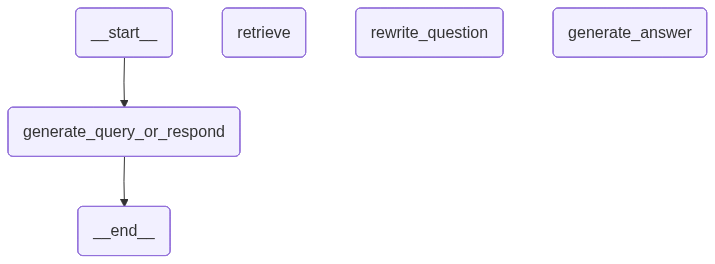

In [51]:
workflow = StateGraph(MessagesState)
workflow.add_node("generate_query_or_respond", generate_query_or_respond)
workflow.add_node("retrieve", ToolNode([retrieve_docs]))
workflow.add_node("rewrite_question", rewrite_question)
workflow.add_node("generate_answer", generate_answer)

workflow.add_edge(START, "generate_query_or_respond")
graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

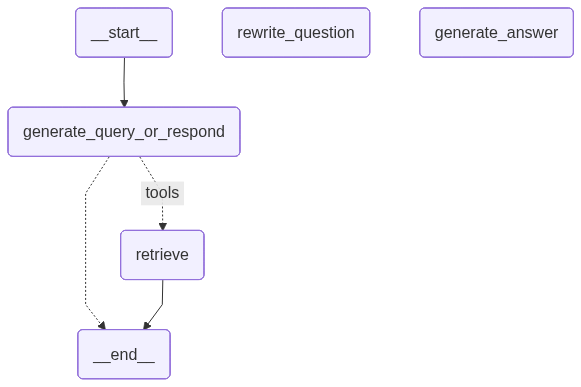

In [52]:
workflow = StateGraph(MessagesState)
workflow.add_node("generate_query_or_respond", generate_query_or_respond)
workflow.add_node("retrieve", ToolNode([retrieve_docs]))
workflow.add_node("rewrite_question", rewrite_question)
workflow.add_node("generate_answer", generate_answer)

workflow.add_edge(START, "generate_query_or_respond")
workflow.add_conditional_edges(
    "generate_query_or_respond",
    tools_condition,
    {
        "tools": "retrieve",
        END: END,
    },
)
graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

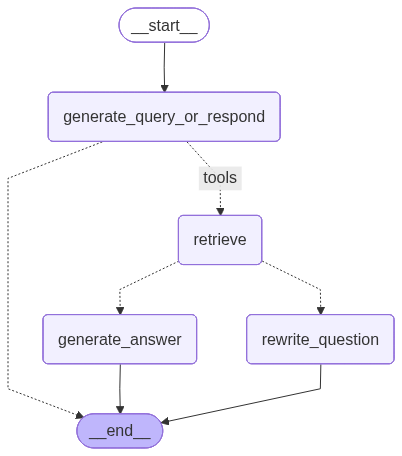

In [58]:
workflow = StateGraph(MessagesState)
workflow.add_node("generate_query_or_respond", generate_query_or_respond)
workflow.add_node("retrieve", ToolNode([retrieve_docs]))
workflow.add_node("rewrite_question", rewrite_question)
workflow.add_node("generate_answer", generate_answer)

workflow.add_edge(START, "generate_query_or_respond")
workflow.add_conditional_edges(
    "generate_query_or_respond",
    tools_condition,
    {
        "tools": "retrieve",
        END: END,
    },
)
workflow.add_conditional_edges(
    "retrieve",
    grade_documents,
    {                                      
        "generate_answer": "generate_answer",
        "rewrite_question": "rewrite_question",
    }
)
graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

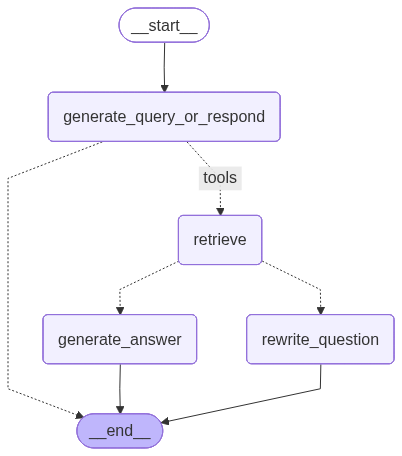

In [57]:
workflow = StateGraph(MessagesState)
workflow.add_node("generate_query_or_respond", generate_query_or_respond)
workflow.add_node("retrieve", ToolNode([retrieve_docs]))
workflow.add_node("rewrite_question", rewrite_question)
workflow.add_node("generate_answer", generate_answer)

workflow.add_edge(START, "generate_query_or_respond")
workflow.add_conditional_edges(
    "generate_query_or_respond",
    tools_condition,
    {
        "tools": "retrieve",
        END: END,
    },
)
workflow.add_conditional_edges(
    "retrieve",
    grade_documents,
    {                                      
        "generate_answer": "generate_answer",
        "rewrite_question": "rewrite_question",
    }
)
workflow.add_edge("generate_answer", END)
graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

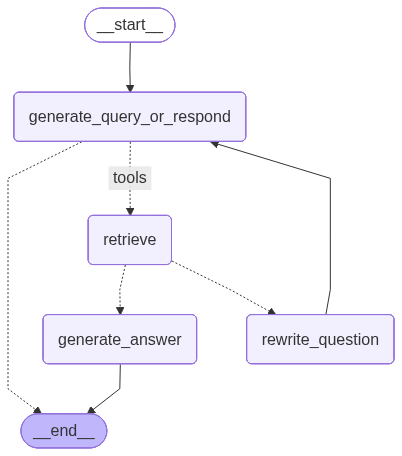

In [ ]:
workflow = StateGraph(MessagesState)
workflow.add_node("generate_query_or_respond", generate_query_or_respond)
workflow.add_node("retrieve", ToolNode([retrieve_docs]))
workflow.add_node("rewrite_question", rewrite_question)
workflow.add_node("generate_answer", generate_answer)

workflow.add_edge(START, "generate_query_or_respond")
workflow.add_conditional_edges(
    "generate_query_or_respond",
    tools_condition,
    {
        "tools": "retrieve",
        END: END,
    },
)
workflow.add_conditional_edges(
    "retrieve",
    grade_documents,
    {                                      
        "generate_answer": "generate_answer",
        "rewrite_question": "rewrite_question",
    }
)
workflow.add_edge("generate_answer", END)
workflow.add_edge("rewrite_question", "generate_query_or_respond")

graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

## Agentic RAG - Multi Hop

In [97]:
# LLM general
llm = ChatOpenAI(
    model=os.getenv("OPENAI_MODEL", "gpt-5.4-mini"),
    api_key=os.getenv("OPENAI_KEY"),
    temperature=0,  # 0 para que las decisiones del agente sean reproducibles
)
# Retriever
all_txt_files = [i for i in os.listdir("data") if i.endswith(".txt")]
print(all_txt_files)

splitter = RecursiveCharacterTextSplitter(
    chunk_size=250,        # un poco más grande que antes para que cada chunk tenga contexto suficiente
    chunk_overlap=10,
    separators=["\n\n", "\n", ". ", " ", ""],
)

all_chunks = []
all_ids = []
all_metas = []

for file in all_txt_files:
    with open(os.path.join("data", file), "r", encoding="utf-8") as f:
        document_i = f.read()
    chunks = splitter.split_text(document_i)
    all_chunks.extend(chunks)
    all_ids.extend([f"{file}_{i}" for i in range(len(chunks))])
    all_metas.extend([{"source": file} for _ in chunks])

print(f"Total chunks: {len(all_chunks)}")
client = chromadb.Client()

# Limpieza si existe la colección
try:
    client.delete_collection(name="agentic-rag-docs")
except Exception:
    pass

class NewEmbeddingFunction(EmbeddingFunction):
    def __init__(self):
        self.model = SentenceTransformer(
            "microsoft/harrier-oss-v1-0.6b",
            trust_remote_code=True,
            model_kwargs={"attn_implementation": "eager", "torch_dtype": "bfloat16"},
            tokenizer_kwargs={"padding_side": "left"},  # hiper-parámetros recomendados por autores: https://huggingface.co/nvidia/llama-embed-nemotron-8b
        )

    def __call__(self, input: Documents) -> Embeddings:
        return self.model.encode(input).tolist()

    @staticmethod
    def name() -> str:
        return "harrier-oss-v1-0.6b"

ef = NewEmbeddingFunction()

collection = client.get_or_create_collection(
    name="agentic-rag-docs",
    metadata={"hnsw:space": "cosine"},
    embedding_function=ef,
)

collection.add(
    documents=all_chunks,
    ids=all_ids,
    metadatas=all_metas,
)

print("Documentos indexados:", collection.count())

@tool
def retrieve_docs(query: str) -> str:
    """Busca información en la base de conocimiento de la empresa"""
    results = collection.query(
        query_texts=[query],
        n_results=10,  # hiper-parámetro por optimizar
    )
    docs = results["documents"][0]
    sources = [m["source"] for m in results["metadatas"][0]]
    # devolvemos texto plano con la fuente, así el LLM puede citar
    return "\n\n".join([f"[{s}] {d}" for s, d in zip(sources, docs)])

# Probar la tool directamente
print(retrieve_docs.invoke({"query": "especificaciones LR-100"}))

llm_with_tools = llm.bind_tools([retrieve_docs])

['08_manual_uso_lr200.txt', '02_producto_lr200_specs.txt', '06_garantias.txt', '10_comparativa_competencia.txt', '03_politica_devoluciones_2023.txt', '07_soporte_contactos.txt', '05_acta_reunion_q3_2024.txt', '01_producto_lr100_specs.txt', '04_politica_devoluciones_2024.txt', '09_incidencias_conocidas.txt']
Total chunks: 53


Loading weights: 100%|██████████| 310/310 [00:00<00:00, 21544.18it/s]


Documentos indexados: 53
[01_producto_lr100_specs.txt] Especificaciones técnicas — Lumina LR-100
Fecha de lanzamiento: marzo de 2022
Estado: en catálogo (pendiente de discontinuación)

[08_manual_uso_lr200.txt] Manual de usuario — Lumina LR-200 (resumen)

[02_producto_lr200_specs.txt] Especificaciones técnicas — Lumina LR-200
Fecha de lanzamiento: septiembre de 2024
Estado: producto estrella

[06_garantias.txt] Garantía estándar por modelo:
- LR-100: 24 meses. Garantía extendida no disponible.
- LR-200: 36 meses. Garantía extendida opcional hasta 60 meses (+59 €).
- LR-Mini (accesorio): 12 meses.
- Baterías de repuesto: 6 meses, no extensibles.

[09_incidencias_conocidas.txt] LR-100:
- Bug F-203: en firmware 1.4 o anterior, el robot puede entrar en bucle al detectar alfombras de tonos oscuros. No hay solución prevista; el modelo está en proceso de discontinuación.

[05_acta_reunion_q3_2024.txt] 3. El LR-200 pasa a ser el modelo de referencia de la marca. El equipo de marketing ajustará

In [98]:
## agentic node

SYSTEM_PROMPT = """Eres un asistente experto con acceso a una herramienta de búsqueda.

PROCESO OBLIGATORIO — sigue estos pasos en orden:

PASO 1 — PLANIFICA antes de buscar:
Escribe explícitamente: "Sub-preguntas: 1)... 2)... 3)..."

PASO 2 — BUSCA de una en una:
- Una query por sub-pregunta, corta y específica
- Usa resultados previos para formular la siguiente query
  Ejemplo: si hop 1 devuelve "modelo LR-100", el hop 2 busca "autonomía LR-100"

PASO 3 — RESPONDE solo cuando hayas buscado TODAS las sub-preguntas
- Si un dato no apareció, haz una búsqueda alternativa antes de rendirte
- Nunca digas "no aparece" sin haber buscado ese dato de forma aislada"""

def generate_query_or_respond(state: MessagesState):
    all_queries = [
        tool_call["args"]["query"]
        for m in state["messages"]
        if isinstance(m, AIMessage) and m.tool_calls
        for tool_call in m.tool_calls
    ]

    all_docs = [
        m.content for m in state["messages"]
        if isinstance(m, ToolMessage)
    ]

    context_block = ""
    if all_queries or all_docs:
        queries_str = "\n".join(f"- {q}" for q in all_queries)
        docs_str = "\n---\n".join(all_docs)
        context_block = f"""

BÚSQUEDAS REALIZADAS:
{queries_str}

CONTEXTO ACUMULADO:
{docs_str}"""

    messages = [SystemMessage(content=SYSTEM_PROMPT + context_block)] + state["messages"]
    return {"messages": [llm_with_tools.invoke(messages)]}

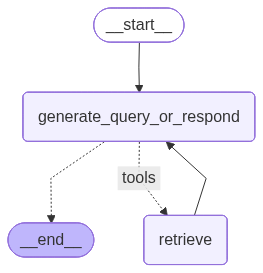

In [99]:
workflow = StateGraph(MessagesState)
workflow.add_node("generate_query_or_respond", generate_query_or_respond)
workflow.add_node("retrieve", ToolNode([retrieve_docs]))

workflow.add_edge(START, "generate_query_or_respond")
workflow.add_conditional_edges(
    "generate_query_or_respond",
    tools_condition,
    {
        "tools": "retrieve",
        END: END,         
    },
)
workflow.add_edge("retrieve", "generate_query_or_respond")  # ← el loop de multi-hop

graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [100]:
pregunta = "¿Qué autonomía tiene el modelo que el CTO recomendó discontinuar?"

for chunk in graph.stream({"messages": [{"role": "user", "content": pregunta}]}):
    for node, update in chunk.items():
        print(f"=== Update desde nodo: {node} ===")
        update["messages"][-1].pretty_print()
        print()


=== Update desde nodo: generate_query_or_respond ===
================================== Ai Message ==================================

Sub-preguntas: 1) ¿Qué modelo recomendó discontinuar el CTO? 2) ¿Cuál es la autonomía de ese modelo? 3) ¿Hay alguna variante o ficha técnica asociada con ese modelo?
Tool Calls:
  retrieve_docs (call_37j8oXcyWUEX3E8BcznUEDHe)
 Call ID: call_37j8oXcyWUEX3E8BcznUEDHe
  Args:
    query: CTO recomendó discontinuar modelo

=== Update desde nodo: retrieve ===
================================= Tool Message =================================
Name: retrieve_docs

[05_acta_reunion_q3_2024.txt] 1. El CTO presenta el plan de simplificación de catálogo. Tras revisar las incidencias acumuladas en el último año, recomienda discontinuar el modelo LR-100 antes del cierre de año

[05_acta_reunion_q3_2024.txt] 5. Se establece una línea de soporte preferente para incidencias del LR-200, dada su criticidad para el negocio.

[05_acta_reunion_q3_2024.txt] 3. El LR-200 pasa a s

## Prompting para Agentic RAG

In [103]:
MIN_QUERIES = 10

def generate_query_or_respond(state: MessagesState):
    all_queries = [
        tool_call["args"]["query"]
        for m in state["messages"]
        if isinstance(m, AIMessage) and m.tool_calls
        for tool_call in m.tool_calls
    ]

    all_docs = [
        m.content for m in state["messages"]
        if isinstance(m, ToolMessage)
    ]

    context_block = ""
    if all_queries or all_docs:
        queries_str = "\n".join(f"- {q}" for q in all_queries)
        docs_str = "\n---\n".join(all_docs)
        context_block = f"""

BÚSQUEDAS REALIZADAS ({len(all_queries)}/{MIN_QUERIES} mínimas):
{queries_str}

CONTEXTO ACUMULADO:
{docs_str}"""

    # ← enforced en código, no en prompt
    if len(all_queries) < MIN_QUERIES:
        # Fuerza tool_call — el LLM no puede responder directo
        response = llm_with_tools.invoke(
            [SystemMessage(content=SYSTEM_PROMPT + context_block)] + state["messages"],
            tool_choice="required",   # ← OpenAI
            # tool_choice={"type": "any"}  # ← Anthropic
        )
    else:
        # Ya cumplió el mínimo — puede responder libremente
        response = llm_with_tools.invoke(
            [SystemMessage(content=SYSTEM_PROMPT + context_block)] + state["messages"],
        )

    return {"messages": [response]}

workflow = StateGraph(MessagesState)
workflow.add_node("generate_query_or_respond", generate_query_or_respond)
workflow.add_node("retrieve", ToolNode([retrieve_docs]))

workflow.add_edge(START, "generate_query_or_respond")
workflow.add_conditional_edges(
    "generate_query_or_respond",
    tools_condition,
    {
        "tools": "retrieve",
        END: END,         
    },
)
workflow.add_edge("retrieve", "generate_query_or_respond")  # ← el loop de multi-hop

graph = workflow.compile()


pregunta = "¿Qué autonomía tiene el modelo que el CTO recomendó discontinuar?"

for chunk in graph.stream({"messages": [{"role": "user", "content": pregunta}]}):
    for node, update in chunk.items():
        print(f"=== Update desde nodo: {node} ===")
        update["messages"][-1].pretty_print()
        print()

=== Update desde nodo: generate_query_or_respond ===
================================== Ai Message ==================================

Sub-preguntas: 1) ¿Qué modelo recomendó discontinuar el CTO? 2) ¿Dónde se describe su autonomía? 3) ¿Cuál es exactamente la autonomía indicada?
Tool Calls:
  retrieve_docs (call_jxa3WhOHdgRHrwDdAeVaMrI0)
 Call ID: call_jxa3WhOHdgRHrwDdAeVaMrI0
  Args:
    query: CTO recomendó discontinuar modelo autonomía

=== Update desde nodo: retrieve ===
================================= Tool Message =================================
Name: retrieve_docs

[05_acta_reunion_q3_2024.txt] 1. El CTO presenta el plan de simplificación de catálogo. Tras revisar las incidencias acumuladas en el último año, recomienda discontinuar el modelo LR-100 antes del cierre de año

[05_acta_reunion_q3_2024.txt] 5. Se establece una línea de soporte preferente para incidencias del LR-200, dada su criticidad para el negocio.

[05_acta_reunion_q3_2024.txt] . El motivo principal son los fal

## Metadatos para recuperación contextual

In [104]:
all_chunks = []
all_ids = []
all_metas = []
for file in all_txt_files:
    with open(os.path.join("data", file), "r", encoding="utf-8") as f:
        document_i = f.read()
    chunks = splitter.split_text(document_i)
    all_chunks.extend([f"[fuente: {file}] {chunk}" for chunk in chunks])  # ← prefijo
    all_ids.extend([f"{file}_{i}" for i in range(len(chunks))])
    all_metas.extend([{"source": file} for _ in chunks])


# Limpieza si existe la colección
try:
    client.delete_collection(name="agentic-rag-docs")
except Exception:
    pass

class NewEmbeddingFunction(EmbeddingFunction):
    def __init__(self):
        self.model = SentenceTransformer(
            "microsoft/harrier-oss-v1-0.6b",
            trust_remote_code=True,
            model_kwargs={"attn_implementation": "eager", "torch_dtype": "bfloat16"},
            tokenizer_kwargs={"padding_side": "left"},  # hiper-parámetros recomendados por autores: https://huggingface.co/nvidia/llama-embed-nemotron-8b
        )

    def __call__(self, input: Documents) -> Embeddings:
        return self.model.encode(input).tolist()

    @staticmethod
    def name() -> str:
        return "harrier-oss-v1-0.6b"

ef = NewEmbeddingFunction()

collection = client.get_or_create_collection(
    name="agentic-rag-docs",
    metadata={"hnsw:space": "cosine"},
    embedding_function=ef,
)

collection.add(
    documents=all_chunks,
    ids=all_ids,
    metadatas=all_metas,
)

print("Documentos indexados:", collection.count())

@tool
def retrieve_docs(query: str) -> str:
    """Busca información en la base de conocimiento de la empresa"""
    results = collection.query(
        query_texts=[query],
        n_results=10,  # hiper-parámetro por optimizar
    )
    docs = results["documents"][0]
    sources = [m["source"] for m in results["metadatas"][0]]
    # devolvemos texto plano con la fuente, así el LLM puede citar
    return "\n\n".join([f"[{s}] {d}" for s, d in zip(sources, docs)])

# Probar la tool directamente
print(retrieve_docs.invoke({"query": "especificaciones LR-100"}))

llm_with_tools = llm.bind_tools([retrieve_docs])

Loading weights: 100%|██████████| 310/310 [00:00<00:00, 2579.51it/s]


Documentos indexados: 53
[01_producto_lr100_specs.txt] [fuente: 01_producto_lr100_specs.txt] Especificaciones técnicas — Lumina LR-100
Fecha de lanzamiento: marzo de 2022
Estado: en catálogo (pendiente de discontinuación)

[08_manual_uso_lr200.txt] [fuente: 08_manual_uso_lr200.txt] Manual de usuario — Lumina LR-200 (resumen)

[02_producto_lr200_specs.txt] [fuente: 02_producto_lr200_specs.txt] Especificaciones técnicas — Lumina LR-200
Fecha de lanzamiento: septiembre de 2024
Estado: producto estrella

[01_producto_lr100_specs.txt] [fuente: 01_producto_lr100_specs.txt] Notas internas: el firmware 1.4 sigue siendo la última versión publicada. No se prevén nuevas actualizaciones.

[06_garantias.txt] [fuente: 06_garantias.txt] Garantía estándar por modelo:
- LR-100: 24 meses. Garantía extendida no disponible.
- LR-200: 36 meses. Garantía extendida opcional hasta 60 meses (+59 €).
- LR-Mini (accesorio): 12 meses.
- Baterías de repuesto: 6 meses, no extensibles.

[02_producto_lr200_specs.txt]

In [106]:
MIN_QUERIES = 3

def generate_query_or_respond(state: MessagesState):
    all_queries = [
        tool_call["args"]["query"]
        for m in state["messages"]
        if isinstance(m, AIMessage) and m.tool_calls
        for tool_call in m.tool_calls
    ]

    all_docs = [
        m.content for m in state["messages"]
        if isinstance(m, ToolMessage)
    ]

    context_block = ""
    if all_queries or all_docs:
        queries_str = "\n".join(f"- {q}" for q in all_queries)
        docs_str = "\n---\n".join(all_docs)
        context_block = f"""

BÚSQUEDAS REALIZADAS ({len(all_queries)}/{MIN_QUERIES} mínimas):
{queries_str}

CONTEXTO ACUMULADO:
{docs_str}"""

    # ← enforced en código, no en prompt
    if len(all_queries) < MIN_QUERIES:
        # Fuerza tool_call — el LLM no puede responder directo
        response = llm_with_tools.invoke(
            [SystemMessage(content=SYSTEM_PROMPT + context_block)] + state["messages"],
            tool_choice="required",   # ← OpenAI
            # tool_choice={"type": "any"}  # ← Anthropic
        )
    else:
        # Ya cumplió el mínimo — puede responder libremente
        response = llm_with_tools.invoke(
            [SystemMessage(content=SYSTEM_PROMPT + context_block)] + state["messages"],
        )

    return {"messages": [response]}

workflow = StateGraph(MessagesState)
workflow.add_node("generate_query_or_respond", generate_query_or_respond)
workflow.add_node("retrieve", ToolNode([retrieve_docs]))

workflow.add_edge(START, "generate_query_or_respond")
workflow.add_conditional_edges(
    "generate_query_or_respond",
    tools_condition,
    {
        "tools": "retrieve",
        END: END,         
    },
)
workflow.add_edge("retrieve", "generate_query_or_respond")  # ← el loop de multi-hop

graph = workflow.compile()


pregunta = "¿Qué autonomía tiene el modelo que el CTO recomendó discontinuar?"

for chunk in graph.stream({"messages": [{"role": "user", "content": pregunta}]}):
    for node, update in chunk.items():
        print(f"=== Update desde nodo: {node} ===")
        update["messages"][-1].pretty_print()
        print()

=== Update desde nodo: generate_query_or_respond ===
================================== Ai Message ==================================

Sub-preguntas: 1) ¿Qué modelo recomendó discontinuar el CTO? 2) ¿Cuál es la autonomía de ese modelo? 3) ¿Hay alguna especificación o variante asociada a esa autonomía?
Tool Calls:
  retrieve_docs (call_OSXfYZQxS6PM9uHq8GoLV6dt)
 Call ID: call_OSXfYZQxS6PM9uHq8GoLV6dt
  Args:
    query: CTO recomendó discontinuar modelo autonomía

=== Update desde nodo: retrieve ===
================================= Tool Message =================================
Name: retrieve_docs

[05_acta_reunion_q3_2024.txt] [fuente: 05_acta_reunion_q3_2024.txt] 1. El CTO presenta el plan de simplificación de catálogo. Tras revisar las incidencias acumuladas en el último año, recomienda discontinuar el modelo LR-100 antes del cierre de año

[05_acta_reunion_q3_2024.txt] [fuente: 05_acta_reunion_q3_2024.txt] . El motivo principal son los fallos recurrentes de firmware sin solución pre

## Tarea en clase

Añadir un LLM que evalue la complejidad del query y decida el tamaño de top_k dentro de valores razonables.

Comparar desempeño de el último Agentic RAG contra su propuesta usando las métricas sugeridas por RAGAS.